# 03 - Model Training & Evaluation

This notebook demonstrates the same training/evaluation workflow that `training/train_model.py` runs as a script. Run this notebook top-to-bottom to see every step interactively, including real evaluation metrics computed on a held-out test set (no fabricated numbers).

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'training'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

from preprocess import build_preprocessor, ALL_FEATURES, TARGET_COLUMN

RANDOM_STATE = 42
DATA_PATH = os.path.join('..', 'backend', 'data', 'career_dataset.csv')
df = pd.read_csv(DATA_PATH)

X = df[ALL_FEATURES]
y = df[TARGET_COLUMN]
classes = sorted(y.unique().tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)

(1760, 22) (440, 22)


## Candidate models

We compare three models, each wrapped in the **same** preprocessing pipeline so the comparison is fair:

1. **RandomForestClassifier** - our primary baseline candidate
2. **LogisticRegression** - a simpler, highly interpretable linear model
3. **GradientBoostingClassifier** - a stronger boosted-tree alternative

In [2]:
candidates = {
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'GradientBoostingClassifier': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE
    ),
}

pipelines = {
    name: Pipeline([('preprocessor', build_preprocessor()), ('classifier', clf)])
    for name, clf in candidates.items()
}

## Train and evaluate each candidate

In [3]:
results = {}
fitted = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
    }
    fitted[name] = pipe

results_df = pd.DataFrame(results).T.sort_values('f1_macro', ascending=False)
results_df

,accuracy,precision_macro,recall_macro,f1_macro
LogisticRegression,0.963636,0.963758,0.963636,0.963550
GradientBoostingClassifier,0.952273,0.953055,0.952273,0.952145
RandomForestClassifier,0.945455,0.947225,0.945455,0.945502


## Model selection

We select the model with the highest **macro F1-score** - macro averaging treats every career class equally, which matters here since we don't want the metric dominated by a few easy-to-classify roles.

In [4]:
best_model_name = results_df.index[0]
best_pipeline = fitted[best_model_name]
print('Selected model:', best_model_name)
print(results_df.loc[best_model_name])

Selected model: LogisticRegression
accuracy           0.963636
precision_macro    0.963758
recall_macro       0.963636
f1_macro           0.963550
Name: LogisticRegression, dtype: float64


## Classification report (selected model)

In [5]:
y_pred_best = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_best, labels=classes, zero_division=0))

                           precision    recall  f1-score   support

              AI Engineer       0.91      0.95      0.93        44
        Backend Developer       0.98      1.00      0.99        44
           Cloud Engineer       0.93      0.93      0.93        44
    Cybersecurity Analyst       1.00      1.00      1.00        44
             Data Analyst       0.98      0.98      0.98        44
           Data Scientist       0.98      0.98      0.98        44
          DevOps Engineer       0.93      0.91      0.92        44
       Frontend Developer       1.00      0.98      0.99        44
     Full Stack Developer       0.98      1.00      0.99        44
Machine Learning Engineer       0.95      0.91      0.93        44

                 accuracy                           0.96       440
                macro avg       0.96      0.96      0.96       440
             weighted avg       0.96      0.96      0.96       440



## Confusion matrix (selected model)

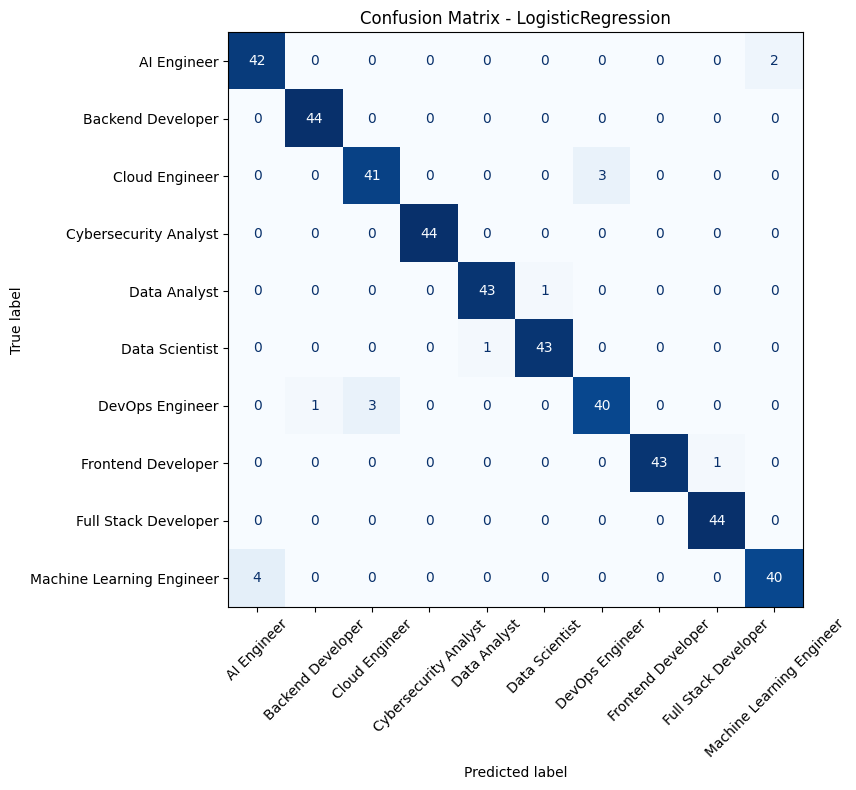

In [6]:
cm = confusion_matrix(y_test, y_pred_best, labels=classes)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
    ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues'
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

## Interpreting the confusion matrix

Most misclassifications, if any, should occur between careers with genuinely overlapping skill profiles (e.g. AI Engineer vs Machine Learning Engineer, or DevOps Engineer vs Cloud Engineer) rather than between unrelated roles - which would suggest the model has learned a sensible, realistic decision boundary rather than noise.

## Saving the final model

The actual saved artifact used by the backend is produced by running:

```bash
python training/train_model.py
```

which performs this exact workflow and writes:
- `backend/models/career_model.joblib` (the fitted pipeline)
- `backend/models/model_metadata.json` (real metrics + metadata)
- `backend/models/confusion_matrix.png`

This notebook is for exploration/explanation; the script is the reproducible source of truth.